In [64]:
import seaborn as sns
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

n_ticks = 5
line_styles = [
    "solid",
    "dotted",
    "dashdot",
    "dashed",
    (5, (10, 3)),
    (0, (3, 1, 1, 1, 1, 1)),
    (5, (10, 3)),
]

result_path = Path("diagrams", "temperature_comparison")
result_path.mkdir(exist_ok=True)

In [65]:
data_set = "breast_cancer"
bias_type = "less_positive_class"
bias_strength = 0.1
method="fw-mrs-temperature"
path = Path(f"../results/temperature_comparison/{data_set}/{bias_type}/{bias_strength}/{method}")

In [66]:
with open(path / "method_aurocs/optimised_method_aurocs.json") as file:
    auroc_with_feature_weights = json.load(file)
with open(path / "metadata.json") as file:
    metadata = json.load(file)

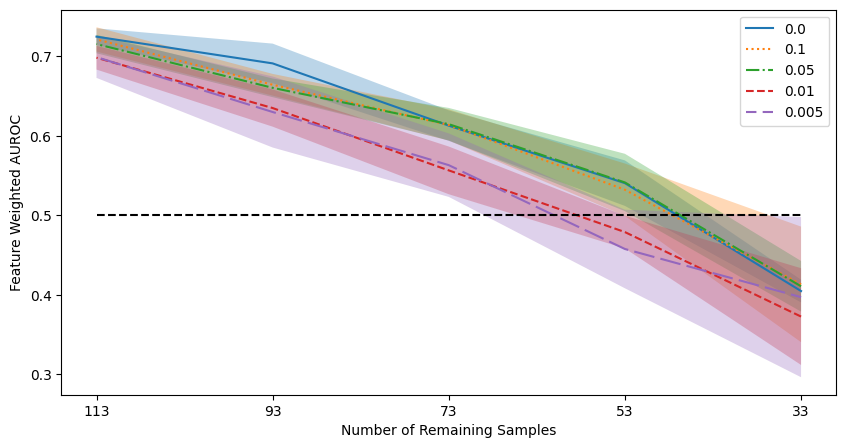

In [67]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights
    ]
)
min_number_of_samples = np.min(metadata["number_of_samples"])
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / "optimised_temperature_comparison_rf.pdf")

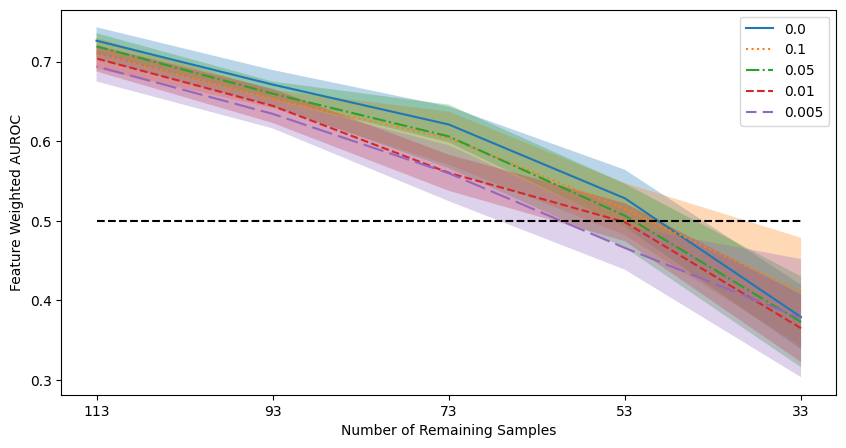

In [68]:
with open(path / "method_aurocs/fixed_method_aurocs.json") as file:
    auroc_with_feature_weights = json.load(file)

plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights
    ]
)
min_number_of_samples = np.min(metadata["number_of_samples"])
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / "fixed_temperature_comparison_rf.pdf")

In [69]:
method="fw-mrs-temperature-svm"
path = Path(f"../results/temperature_comparison/{data_set}/{bias_type}/{bias_strength}/{method}")

with open(path / "method_aurocs/optimised_method_aurocs.json") as file:
    auroc_with_feature_weights_svm = json.load(file)
with open(path / "metadata.json") as file:
    metadata = json.load(file)

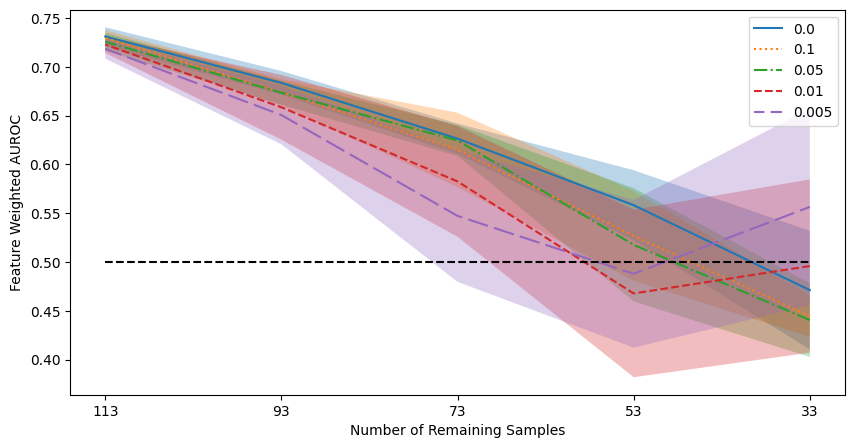

In [70]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights_svm
    ]
)
min_number_of_samples = np.min(metadata["number_of_samples"])
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights_svm[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights_svm:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / "optimised_temperature_comparison_svm.pdf")

In [71]:
with open(path / "method_aurocs/fixed_method_aurocs.json") as file:
    auroc_with_feature_weights_svm = json.load(file)

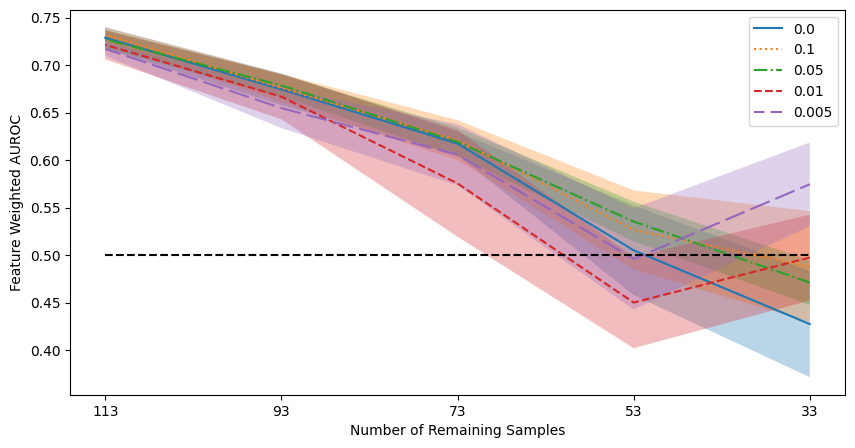

In [72]:
plt.figure(figsize=(10, 5))
min_length = np.min(
    [
        [len(auroc_list) for auroc_list in auroc_lists.values()]
        for auroc_lists in auroc_with_feature_weights_svm
    ]
)
min_number_of_samples = np.min(metadata["number_of_samples"])
x_labels = list(range(min_number_of_samples, 0, -metadata["n_dropped"]))[:min_length]
for i, budget in enumerate(auroc_with_feature_weights_svm[0].keys()):
    auroc_list = []
    for dictionary in auroc_with_feature_weights_svm:
        dictionary = {float(k): v for k, v in dictionary.items()}
        auroc_list.append(dictionary[float(budget)][:min_length])
    mean_aurocs = np.mean(auroc_list, axis=0)
    std_aurocs = np.std(auroc_list, axis=0)
    ratio_upper = mean_aurocs + std_aurocs
    ratio_lower = (mean_aurocs - std_aurocs).clip(min=0)
    sns.lineplot(
        x=x_labels, y=mean_aurocs, label=str(budget), linestyle=line_styles[i]
    )
    plt.fill_between(x_labels, ratio_lower, ratio_upper, alpha=0.3)
plt.plot(
    [min_number_of_samples, x_labels[-1]], [0.5, 0.5], color="black", linestyle="--"
)
plt.ylabel("Feature Weighted AUROC")
plt.xlabel("Number of Remaining Samples")
step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(result_path / "fixed_temperature_comparison_svm.pdf")